# Habermas Machine Dataset Example Usage
This notebook demonstrates basic usage of the Habermas Machine dataset using ConvoKit.
We will explore the dataset size, conversational structure, and how AI mediation shifts user opinions.


In [1]:
import convokit
from convokit import Corpus
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import numpy as np

# Load corpus
corpus = Corpus(filename="../habermas_machine_processing/habermas-machine-corpus")
corpus.print_summary_stats()


Number of Speakers: 7191
Number of Utterances: 46083
Number of Conversations: 4492


## 1. Analyzing the Conversational Structure
In this dataset, conversations follow a strict pipeline. We can see how many utterances belong to each phase.


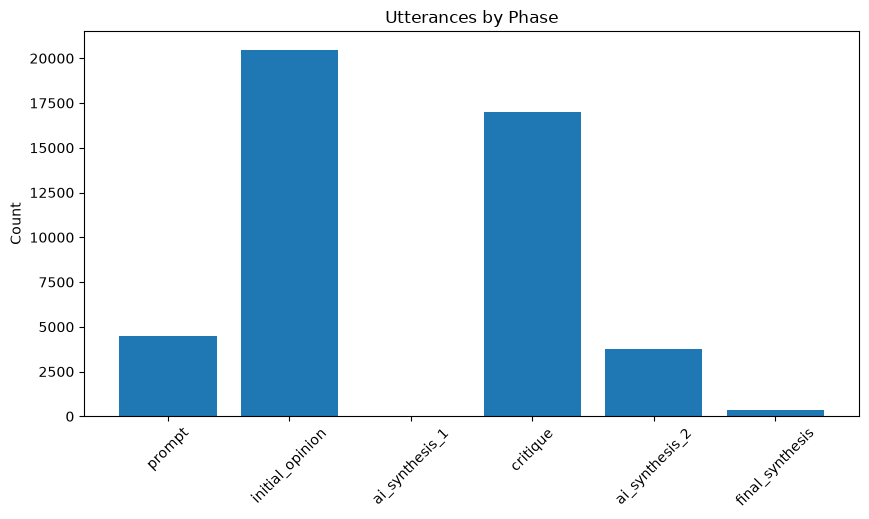

In [2]:
phases = Counter()
for utt in corpus.iter_utterances():
    phases[utt.meta.get('phase', 'unknown')] += 1

plt.figure(figsize=(10, 5))
plt.bar(phases.keys(), phases.values())
plt.title("Utterances by Phase")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


## 2. Opinion Shifts Before and After Deliberation
A core focus of this dataset is analyzing how human opinions shift after engaging in a deliberation mediated by the AI.
Let's map the stances to a numerical scale and calculate the average opinion shift towards agreement.


Total participants with valid stance data: 18550
Average absolute opinion shift: 0.86 steps


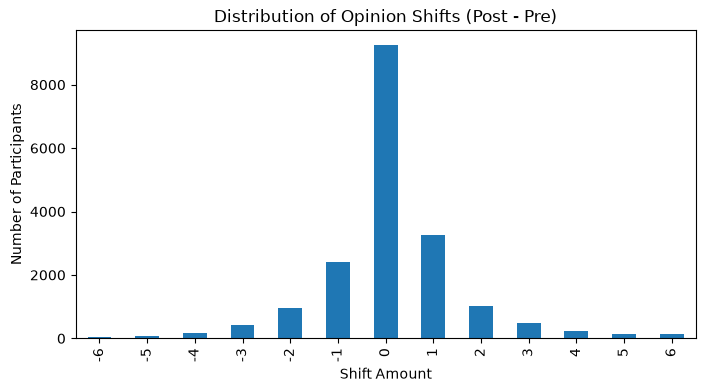

In [3]:
stance_map = {
    'STRONGLY_DISAGREE': -3,
    'DISAGREE': -2,
    'SOMEWHAT_DISAGREE': -1,
    'NEUTRAL': 0,
    'SOMEWHAT_AGREE': 1,
    'AGREE': 2,
    'STRONGLY_AGREE': 3
}

shifts = []
for convo in corpus.iter_conversations():
    stances = convo.meta.get('participant_stances', {})
    for pid, stance_dict in stances.items():
        pre = stance_dict.get('pre_deliberation_stance')
        post = stance_dict.get('post_deliberation_stance')
        if pre in stance_map and post in stance_map:
            # We measure absolute shift (strength of conviction change) and directional shift
            shifts.append({
                'topic': convo.meta.get('topic'),
                'pre': stance_map[pre],
                'post': stance_map[post],
                'shift': stance_map[post] - stance_map[pre],
                'abs_shift': abs(stance_map[post] - stance_map[pre])
            })

df = pd.DataFrame(shifts)
print(f"Total participants with valid stance data: {len(df)}")
print(f"Average absolute opinion shift: {df['abs_shift'].mean():.2f} steps")

# Plot distribution of shifts
plt.figure(figsize=(8, 4))
df['shift'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Opinion Shifts (Post - Pre)")
plt.xlabel("Shift Amount")
plt.ylabel("Number of Participants")
plt.show()


## 3. ConvoKitAI Features
This dataset leverages the new `convokitai` formatting. We can import specific AI-centric classes like `Speaker`, `Conversation`, and `Corpus` from `convokit.convokitai` to expose new AI functionalities like `is_ai` and `ai_meta`.


In [4]:
from convokitai import Corpus as AICorpus
# Reload corpus using ConvoKitAI's Corpus
ai_corpus = AICorpus(filename="../habermas_machine_processing/habermas-machine-corpus")

# Verify AI speaker properties
ai_mediator = ai_corpus.get_speaker('ai_mediator')
print(f"Is ai_mediator an AI? {ai_mediator.is_ai}")
print(f"AI Meta for mediator: {ai_mediator.ai_meta}")

# We can also check humans!
human_speaker = next(s for s in ai_corpus.iter_speakers() if s.id != 'ai_mediator' and s.id != 'system_moderator')
print(f"Is human speaker {human_speaker.id} an AI? {human_speaker.is_ai}")
print(f"Human Meta: {human_speaker.ai_meta}")


Is ai_mediator an AI? True
AI Meta for mediator: {'role': 'mediator'}
Is human speaker 1788a6f444 an AI? False
Human Meta: {'role': 'participant'}
